In [1]:
import pandas as pd

# 원본 불러오기
raw = pd.read_csv("../../data/16_machine-failure.csv")
target_col = "Machine failure"
feature_cols = [c for c in raw.columns if c != target_col]

# ① 빈칸 비율 50% 이상, 상수열(nunique==1), 또는 거의 안 변하는 숫자열(std<=0.001) 제거
drop_cols = []
for c in feature_cols:
    na_ratio = raw[c].isna().mean()
    if na_ratio >= 0.5:
        drop_cols.append(c)
        continue
    if raw[c].nunique(dropna=True) == 1:
        drop_cols.append(c)
        continue
    if pd.api.types.is_numeric_dtype(raw[c]) and raw[c].std() <= 0.001:
        drop_cols.append(c)

df1 = raw.drop(columns=drop_cols)
print("제거된 열(빈칸/상수):", drop_cols)

# ② 상관계수 절댓값 0.9 이상인 숫자열 짝마다, 빈칸이 더 많은 쪽 제거(중복 정리)
num_cols = [c for c in df1.columns if c != target_col and pd.api.types.is_numeric_dtype(df1[c])]
corr = df1[num_cols].corr().abs()

dedup_drop = set()
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        a, b = num_cols[i], num_cols[j]
        if a in dedup_drop or b in dedup_drop:
            continue
        if corr.loc[a, b] >= 0.9:
            na_a, na_b = df1[a].isna().sum(), df1[b].isna().sum()
            dedup_drop.add(b if na_a <= na_b else a)

df2 = df1.drop(columns=list(dedup_drop))
print("제거된 열(상관 중복):", list(dedup_drop))

# 정제본 저장 후 다시 불러오기
df2.to_csv("results/16_machine-failure_clean.csv", index=False)
df = pd.read_csv("results/16_machine-failure_clean.csv")

# 전체 행 수와 열 개수
print("행", df.shape[0], "/ 열", df.shape[1])

# Machine failure 값별 건수와 비율
건수 = df["Machine failure"].value_counts()
비율 = (df["Machine failure"].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"건수": 건수, "비율(%)": 비율}))

제거된 열(빈칸/상수): []
제거된 열(상관 중복): []
행 10000 / 열 7
                   건수  비율(%)
Machine failure             
정상               9661   96.6
고장                339    3.4


## Step 1. 문제 정의

**한 문장** : 설비 센서 측정값(온도·회전속도·토크·공구 마모)으로, 고장이 나기 전에 고장 가능성이 높은 설비를 먼저 골라낸다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 설비 정비 담당자 |
| 무엇을 결정하나 | 이 설비를 정밀 점검(예방 정비)으로 보낼지 말지 |
| 언제 결정하나 | 센서 측정값이 표에 올라온 직후 |
| 이 판단이 늦으면 | 고장이 라인을 세운 뒤에야 발견되어, 생산이 멈추고 수리 비용과 가동중단 손실이 커진다 |

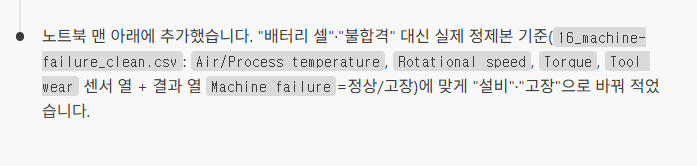

## 후보 비교 - 이 데이터로 풀 수 있는 문제 3개

| 후보 | 결과 열 | 누가 쓰나 | 무엇을 결정하나 | 언제 결정하나 |
|---|---|---|---|---|
| ① 고장 예측(실시간) | Machine failure | 설비 정비 담당자 | 이 설비를 정밀 점검(예방 정비)으로 보낼지 말지 | 센서 측정값(Air temperature, Process temperature, Rotational speed, Torque, Tool wear)이 표에 올라온 직후 |
| ② 고장 예측(작업 단위) | Machine failure | 생산 라인 관리자 | 이번 작업(교대·배치)에서 해당 설비를 계속 돌릴지, 가동을 멈추고 순서를 바꿀지 | 한 작업 구간의 센서 측정값이 다 쌓인 시점 |
| ③ 제품 등급 검증 | Type | 품질관리 담당자 | 센서로 측정된 성능이 신고된 등급(L/M/H)과 맞는지, 재분류가 필요한지 | 출하 전, 센서 측정값이 표에 올라온 직후 |

①·②는 같은 결과 열(Machine failure)이지만 "누가·언제"가 달라서 다른 문제다: ①은 설비 하나하나를 실시간으로 보는 것이고, ②는 작업 구간 단위로 묶어서 라인 운영을 결정하는 것

## Step 2. 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | data/16_machine-failure.csv (정제 후 사용) |
| 규모 | 10000행 x 7열 |
| 입력으로 쓸 열 | 숫자로 된 측정 열 5개 (Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]) |
| 결과 열 (TARGET) | Machine failure |
| 결과 열의 값 | 정상 / 고장 |
| 기준선이 될 숫자 | 고장 339건 (3.4%) |

## Step 3. 한계

- `Type`(설비·제품 등급: L/M/H)이 표에 있지만, 정제본 입력에는 숫자 열 5개만 썼다. 등급별 차이는 아직 보지 않았다
- 이 데이터에는 시간·날짜를 나타내는 열이 아예 없어서, 계절이나 부품 교체 같은 긴 흐름이 담겨 있는지조차 확인할 수 없다
- 특정 측정값(예: `Torque [Nm]`, `Tool wear [min]`)이 높은 구간에서 고장이 많이 관찰되더라도, 그것이 원인이라고는 말할 수 없다